# `sciml` tutorial

This notebook presents a complete example of how to use the `sciml` package to solve, with a PINN, the one-dimensional steady-state advection–diffusion problem parametrized by the Peclet number.

**Problem definition:**

$$
    \begin{cases}
        u_{xx} - Pe u_x = 0,
        & (x, Pe) \in [0, 1] \times [0, 10], \\
        u(0, Pe) = 1,
        & Pe \in [0, 10], \\
        u(1, Pe) = 0,
        & Pe \in [0, 10].
    \end{cases}
$$

**Analytical solution:**

$$
    u(x, Pe) = \frac{1 - \exp(Pe(x - 1))}{1 - \exp(-Pe)}.
$$

### 1. Import packages
---

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch.cuda')

import numpy as np
import torch
import matplotlib.pyplot as plt

from sciml.interfaces import ModelBase

from sciml.core import Objective, Strategy, Trainer

from sciml.implementations.losses import Residual, Supervised
from sciml.implementations.samplers import LatinHypercube
from sciml.implementations.metrics import MaxError, MeanAbsoluteError

### 2. Parameters definition
---

In [2]:
# torch device and dtype
device = "cpu"
dtype = torch.float32

# Problem domain
peclet_min = 0.0
peclet_max = 10.0

# Neural network
input_dim = 2               # (x, Pe)
output_dim = 1              # phi
hidden_layers = (32, 32)

# Samples
num_residual = 2000
num_boundary = 500

# Training
num_iterations = 2020

# Results
results_path = "./results/t1/"

### 3. Analytical solution
---

Functino definition

In [3]:
def solution(x: np.ndarray, peclet: np.ndarray) -> np.ndarray:
    eps = 1e-3
    peclet = np.clip(peclet, eps, None)   # evita divisão por zero em Pe=0
    return (1 - np.exp(peclet * (x - 1))) / (1 - np.exp(-peclet))

Field visualization

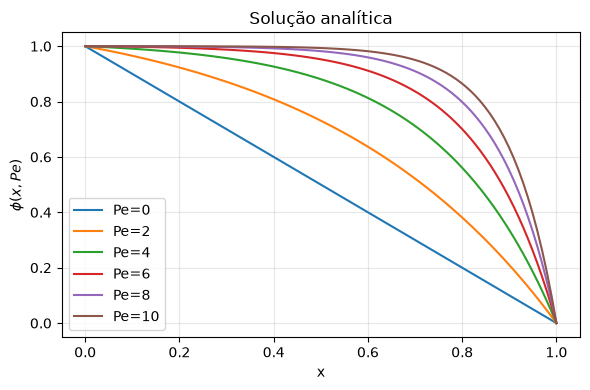

In [4]:
x_plot = np.linspace(0, 1, 100).reshape(-1, 1)

plt.figure(figsize=(6, 4))
for pe_val in np.arange(peclet_min, peclet_max + 1, 2):
    pe_plot = np.full_like(x_plot, pe_val)
    plt.plot(x_plot, solution(x_plot, pe_plot), label=f"Pe={pe_val:.0f}")

plt.xlabel("x")
plt.ylabel(r"$\phi(x, Pe)$")
plt.title("Solução analítica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Components
---

#### 4.1. Model

In [5]:
# Fully connected neural network
class MLP(torch.nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_layers=(32, 32)):
        super().__init__()

        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(torch.nn.Linear(previous_dim, hidden_dim))
            layers.append(torch.nn.Tanh())
            previous_dim = hidden_dim
        layers.append(torch.nn.Linear(previous_dim, output_dim))

        self.net = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Model implementation
class Model(ModelBase):
    def __init__(self):
        self.network = MLP(input_dim, output_dim, hidden_layers).to(device, dtype)
        return
    
    def compute(self, context) -> None:
        context.requires_grad("x")
        inputs = torch.cat([context["x"], context["peclet"]], dim=1)
        context["phi"] = self.network(inputs)
        return

# Model difinition
model = Model()

### 4.2. Losses

In [6]:
# Residual function
def residual(context) -> torch.Tensor:
    phi_x, key = context.partial("phi", "x")
    phi_xx, _ = context.partial(key, "x")
    peclet = context["peclet"]
    return (phi_xx - peclet * phi_x) / (1.0 + peclet)

# Losses definition
residual_loss = Residual(
    name="residual",
    weight=1.0,
    residual=residual,
)

left_bc_loss = Supervised(
    name="left_bc",
    weight=10.0,
    input_keys=["phi"],
    target_keys=["target"],
)

right_bc_loss = Supervised(
    name="right_bc",
    weight=10.0,
    input_keys=["phi"],
    target_keys=["target"],
)

### 4.3. Samplers

In [7]:
# Interior points
residual_sampler = LatinHypercube(
    dim=2,
    num_points=num_residual,
    batch_size=num_residual,
    input_keys=["x", "peclet"],
    bounds=[(1, (peclet_min, peclet_max))],
    device=device,
    dtype=dtype,
)

# Boundary points
left_bc_sampler = LatinHypercube(
    dim=2,
    num_points=num_boundary,
    batch_size=num_boundary,
    input_keys=["x", "peclet"],
    bounds=[(1, (peclet_min, peclet_max))],
    insertions=[(0, 0.0)],
    target_keys=["target"],
    target_fn=solution,
    seed=1,
    device=device,
    dtype=dtype,
)

right_bc_sampler = LatinHypercube(
    dim=2,
    num_points=num_boundary,
    batch_size=num_boundary,
    input_keys=["x", "peclet"],
    bounds=[(1, (peclet_min, peclet_max))],
    insertions=[(0, 1.0)],
    target_keys=["target"],
    target_fn=solution,
    seed=2,
    device=device,
    dtype=dtype,
)

### 4.4. Optimization strategy

In [8]:
# Residual and boundary objectives
objectives = [
    Objective("residual", residual_sampler, [residual_loss]),
    Objective("left_bc", left_bc_sampler, [left_bc_loss]),
    Objective("right_bc", right_bc_sampler, [right_bc_loss]),
]

# Strategy based only on Adam optimizer
strategies = [
    Strategy(
        name="adam",
        optimizer=torch.optim.Adam(model.network.parameters()),
        enable=lambda iteration: iteration < 2000,
    ),
    Strategy(
        name="lbfgs",
        optimizer=torch.optim.LBFGS(model.network.parameters()),
        enable=lambda iteration: iteration >= 2000,
    ),
]

# Trainer definition
trainer = Trainer(
    model=model,
    objectives=objectives,
    strategies=strategies,
    results_path=results_path,
)

## 5. Optimization
---

In [9]:
trainer.fit(num_iterations=num_iterations, verbose=True)

Iteration 2020 - 133.2 it/s
- adam : func = 6.053e-03; ratio = 8.792e-04 [inactive]
- lbfgs: func = 3.429e-05; ratio = 1.161e-02 [active]


## 6. Post-processing
---

Visualize predicted field

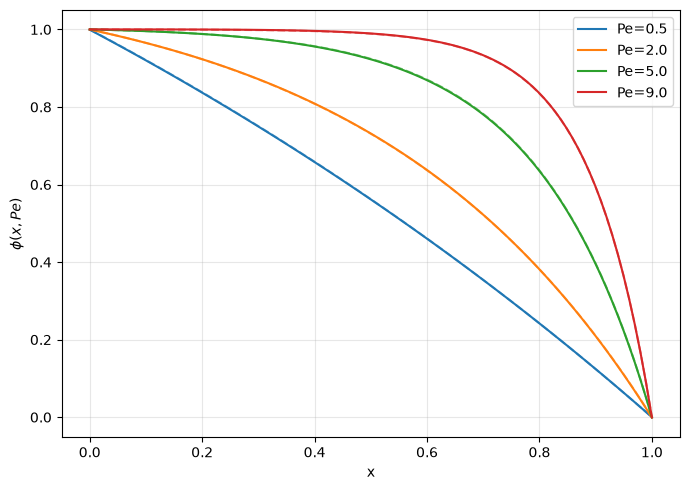

In [10]:
model.network.eval()

x_plot = np.linspace(0, 1, 100).reshape(-1, 1)
peclet_values = [0.5, 2.0, 5.0, 9.0]

plt.figure(figsize=(7, 5))
for pe_val in peclet_values:
    pe_plot = np.full_like(x_plot, pe_val)

    u_ref = solution(x_plot, pe_plot)

    with torch.no_grad():
        inputs = torch.as_tensor(np.concatenate([x_plot, pe_plot], axis=1), dtype=dtype)
        u_pred = model.network(inputs).numpy()

    line, = plt.plot(x_plot, u_pred, label=f"Pe={pe_val:.1f}")
    plt.plot(x_plot, u_ref, "--", color=line.get_color(), alpha=0.6)

plt.xlabel("x")
plt.ylabel(r"$\phi(x, Pe)$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Error for different peclet numbers

In [11]:
# Erro relativo (norma L2) para cada Pe, usando a mesma métrica do pacote
max_error = MaxError()
mae = MeanAbsoluteError()

for pe_val in peclet_values:
    pe_plot = np.full_like(x_plot, pe_val)
    phi_ref = solution(x_plot, pe_plot)

    with torch.no_grad():
        inputs = torch.as_tensor(np.concatenate([x_plot, pe_plot], axis=1), dtype=dtype)
        phi_pred = model.network(inputs).numpy()

    error_1 = max_error.evaluate(torch.as_tensor(phi_pred), torch.as_tensor(phi_ref))
    error_2 = mae.evaluate(torch.as_tensor(phi_pred), torch.as_tensor(phi_ref))

    print(f"Pe={pe_val:4.1f}   max_error = {error_1.item():.4f}; mae = {error_2.item():.4f}")

Pe= 0.5   max_error = 0.0009; mae = 0.0005
Pe= 2.0   max_error = 0.0009; mae = 0.0004
Pe= 5.0   max_error = 0.0016; mae = 0.0009
Pe= 9.0   max_error = 0.0006; mae = 0.0004
